# In-situ Electrochemical SAXS analysis

In [4]:
# %matplotlib widget
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
import glob
import os
import numpy as np
import pandas as pd
# import scienceplots
from galvani import BioLogic as BL
import eclabfiles as ecf
from datetime import datetime, timedelta
import ipywidgets as widgets
from IPython.display import display
from pybaselines import Baseline, utils
import h5py


# Define Functions

# Function for reading files 

In [89]:
# Read HDF5 Data Function with Electrochemical Data (optional)
def read_hdf5_data(hdf5_file_path):
    with h5py.File(hdf5_file_path, 'r') as hdf5_file:
        saxs_data = {}
        waxs_data = {}
        time_stamp_saxs = {}
        time_stamp_waxs = {}
        electrochemical_data = {}  # For electrochemical data

        # Reading SAXS data
        if 'SAXS' in hdf5_file:
            for key in hdf5_file['SAXS'].keys():
                saxs_data[key] = pd.DataFrame(hdf5_file['SAXS'][key][:])
                time_stamp_saxs[key] = hdf5_file['SAXS'][key].attrs['timestamp']

        # Reading WAXS data
        if 'WAXS' in hdf5_file:
            for key in hdf5_file['WAXS'].keys():
                waxs_data[key] = pd.DataFrame(hdf5_file['WAXS'][key][:])
                time_stamp_waxs[key] = hdf5_file['WAXS'][key].attrs['timestamp']

        # Check if electrochemical data is available and read only the "data" part
        if 'ElectrochemicalData' in hdf5_file:
            if 'data' in hdf5_file['ElectrochemicalData']:
                electrochemical_data = pd.DataFrame(hdf5_file['ElectrochemicalData']['data'][:])

        if 'Backgrounds' in hdf5_file:
            if 'SAXS' in hdf5_file['Backgrounds']:
                for key in hdf5_file['Backgrounds']['SAXS'].keys():
                    SAXS_background = pd.DataFrame(hdf5_file['Backgrounds']['SAXS'][key][:])

        if 'Backgrounds' in hdf5_file:
            if 'WAXS' in hdf5_file['Backgrounds']:
                for key in hdf5_file['Backgrounds']['WAXS'].keys():
                    WAXS_background = pd.DataFrame(hdf5_file['Backgrounds']['WAXS'][key][:])

        return saxs_data, time_stamp_saxs, waxs_data, time_stamp_waxs, electrochemical_data,SAXS_background, WAXS_background


In [92]:
hdf5_file_path = r'C:\Users\b1104371\OneDrive - Universität Salzburg\SAXS_backup\Electrolyte_variation\After_Beamtime\2503SKJB\20240820_2503SKJB_satDME_200HFE_120uL_1G1PS\cycle\20240820_satDME.h5'
saxs_data, time_stamp_saxs, waxs_data, time_stamp_waxs, elec_df_temp, SAXS_background, WAXS_background = read_hdf5_data(hdf5_file_path)

# Example: Print the number of SAXS and WAXS files
print(f"Number of SAXS files: {len(saxs_data)}")
print(f"Number of WAXS files: {len(waxs_data)}")

Number of SAXS files: 1254
Number of WAXS files: 1254


# Find files corresponding to Electrochemical events

In [63]:
def find_nearest_time(target_time, time_dict):
    new_time_dict = {}
    keys = list(time_dict.keys())
    base_time = datetime.strptime(time_dict[keys[0]], '%Y-%m-%dT%H:%M:%S')
    count = 0
    for entry in time_dict:
        current_time = datetime.strptime(time_dict[entry], '%Y-%m-%dT%H:%M:%S')
        time_difference = (current_time - base_time).total_seconds()
        new_time_dict[time_difference] = count
        count += 1
    nearest_time_difference = min(new_time_dict, key=lambda x: abs(x - target_time))
    nearest_key = new_time_dict[nearest_time_difference]
    return nearest_key, new_time_dict


# Function for the contour plots

In [102]:
# Function contour plots 
def contourplot(plot_type, data_normalization, data_dictionary, new_time_dict, min_limit, max_limit, cmap_min = None, cmap_max = None):
    import matplotlib.ticker as mticker
    
    plt.style.use('default')
    keys = list(new_time_dict.keys())
    file_names = list(data_dictionary.keys())
    time_t1 = []
    Intensity_list = []
    print(starting_file,discharge_file, last_file)
    X1_data_temp = 10*data_dictionary[file_names[starting_file]].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 

    indices_within_range = np.where((X1_data_temp >= min_limit) & (X1_data_temp <= max_limit))
    #print("Positions where data is within the range:", indices_within_range)

    X1_data_filtered_positions = X1_data_temp.iloc[indices_within_range]
    #print("Values at positions within the range:", X1_data_filtered_positions)
    start_row = np.min(indices_within_range)
    end_row = np.max(indices_within_range)

    # print('valuesof rows', start_row, end_row)

    for file_number in range(starting_file, last_file+1):  
        if data_normalization == 'relative':
            Y1_data = [(data_dictionary[file_names[file_number]].iloc[start_row:end_row+1,1])/data_dictionary[file_names[discharge_file]].iloc[start_row:end_row+1,1]]
        else:
            Y1_data = [(data_dictionary[file_names[file_number]].iloc[start_row:end_row+1,1])]
        time_t1.append(int(keys[file_number-1]-keys[starting_file-1]))   # The '-1' is because the time keys actually start from 0 whereas the file numbers start from 1.     
        Intensity_list.append(list(Y1_data))   

    #print(norm_intensity)
    normIntensity_array = np.array(Intensity_list)
    #print(normIntensity_array)
    X, Y = np.meshgrid(X1_data_filtered_positions, time_t1)
    normIntensity_flat = normIntensity_array[:, 0, :]

    cmap1 = plt.colormaps.get_cmap('viridis')  

    # data for the charge-discharge plot
    relative_time = (elec_df_2[2] - elec_df_2[2].iloc[0])
    # Finding minimum and maximum times to limit the axs from having automatic margins in subplot
    min_time = relative_time.min()
    max_time = relative_time.max()

    fig, axs = plt.subplots(1,2, figsize = (8,5), sharey = True, gridspec_kw = {'width_ratios': [1,4]})
    axs[0].plot(elec_df_2[6], relative_time,  color = 'r')

    # plot1.set_xlabel('Time(s)')
    axs[0].invert_xaxis()
    axs[0].set_ylabel('Time (s)')
    axs[0].set_xlabel('Potential (V)')
    axs[0].set_ylim(min_time, max_time)

    contour = axs[1].contourf(X, Y,normIntensity_flat, cmap = cmap1, vmin=cmap_min, vmax=cmap_max)
    
    if data_normalization == 'relative':
        cbar = fig.colorbar(contour, ax = axs[1], label = 'Ralative intensity (a.u.)')
    else:
        cbar = fig.colorbar(contour, ax = axs[1], label = 'Intensity (a.u.)')

    
    # Adjust the space between the two subplots
    fig.subplots_adjust(wspace = 0)
    axs[1].set_xlabel('q (nm $^{-1}$)')
    if plot_type == 'saxs':
        axs[1].set_xscale('log')
        axs[1].xaxis.set_major_formatter(mticker.ScalarFormatter())
        axs[1].xaxis.set_minor_formatter(mticker.ScalarFormatter())
        

        # Define custom ticks and labels
        ticks = np.arange(min_limit, max_limit, 0.5)
        tick_labels = [f'{tick:.1f}' for tick in ticks]

        axs[1].set_xticks(ticks)
        axs[1].set_xticklabels(tick_labels)
        axs[1].xaxis.set_minor_locator(mticker.NullLocator())  # Remove minor ticks
    
    return

# Plot Data

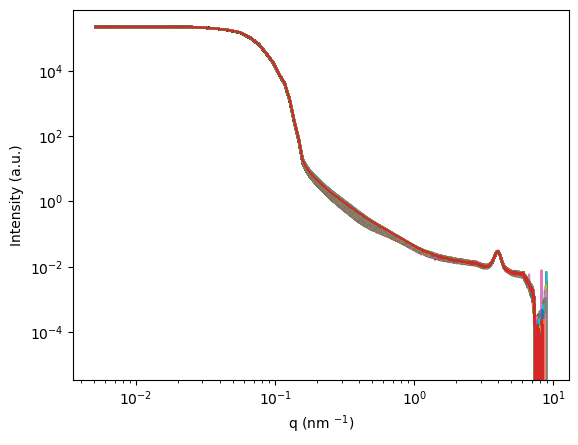

In [14]:
plt.figure()

plt.style.use('default')
for ikey in saxs_data:
    X_data = 10*saxs_data[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = saxs_data[ikey].iloc[:,1]
    plt.plot(X_data, Y_data)
    
#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')

plt.xscale('log')
plt.yscale('log')

# Load electrochemical (EC Lab) file

Indices for cycle change [961, 7817, 14451, 21011, 27399, 33569, 39670, 45435, 51095, 51905, 51907]

Absolute times for change in electrochemical state: 
[960.00037574835, 35227.318953969865, 68386.7453360986, 101173.79378058692, 133100.59562584397, 163939.07145088539, 194431.8802218414, 223243.98032983532, 251529.01835535956, 255568.09218732174, 255568.0933873218]


Text(0, 0.5, 'Potential (V)')

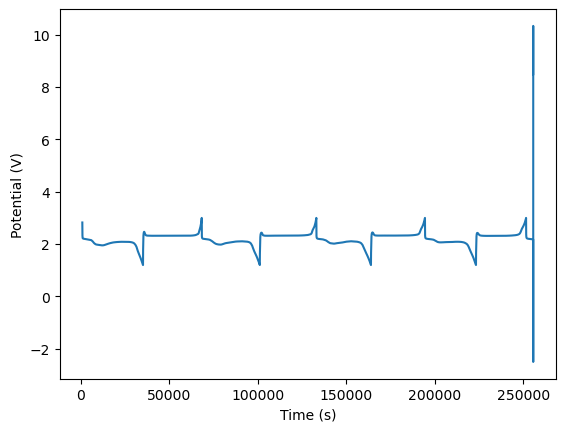

In [31]:
plt.figure()

filter = elec_df_temp[1] != 0
elec_df = elec_df_temp[filter]

    # Track the diffent times for charge-discharge by noting when the Ns value changes

cycle_change_index = []
absolute_times_for_electrochemical_state_change = []

# Add the very first values of the index and time 
cycle_change_index.append(elec_df.index[0])
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[0],2])

for line in range(len(elec_df[1])-1):
    if elec_df[1].iloc[line] != elec_df[1].iloc[line+1]:
        cycle_change_index.append(elec_df.index[line+1])
        absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 2])

cycle_change_index.append(elec_df.index[line+1]) #Takes the index for the last file also  
absolute_times_for_electrochemical_state_change.append(elec_df.loc[elec_df.index[line+1], 2])

print("Indices for cycle change", cycle_change_index)
print("\nAbsolute times for change in electrochemical state: ")
print(absolute_times_for_electrochemical_state_change)

# Plot the read electrochemical file
Elec_Xdata = elec_df[2]
Elec_Ydata = elec_df[6]
plt.plot(Elec_Xdata,Elec_Ydata)
plt.xlabel('Time (s)')
plt.ylabel('Potential (V)')

# Data segregation 

Total number of cycles: 5

Biologic data file line details:
Line numbers for each electrochemical change event : [961, 7817, 14451, 21011, 27399, 33569, 39670, 45435, 51095]
Corresponding times for each electrochemical change event:  ['960.00', '35227.32', '68386.75', '101173.79', '133100.60', '163939.07', '194431.88', '223243.98', '251529.02']
Files numbers for SAXS data [5, 174, 337, 498, 655, 807, 956, 1098, 1236]


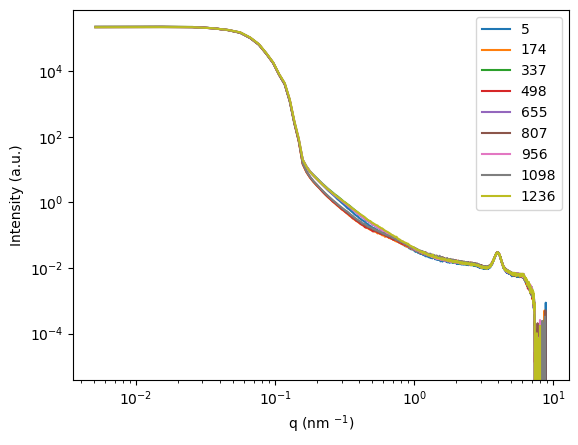

In [67]:
print('Total number of cycles:', len(cycle_change_index)//2)

# Filter the DataFrame by the condition
starting_cycle = int(input("Starting cycle to plot:"))
end_cycle = int(input("Final cycle to plot:"))
file_names = list(saxs_data.keys())

change_cycle_line = []
discharge_start_time = []
saxs_file_numbers = []

starting_index_for_EC_data = 2*starting_cycle-2
ending_index_for_EC_data = 2*end_cycle

print('\nBiologic data file line details:')
print('Line numbers for each electrochemical change event :',
       [cycle_change_index[_] for _ in range(starting_index_for_EC_data, ending_index_for_EC_data+1)])
print('Corresponding times for each electrochemical change event: ', 
      [f"{absolute_times_for_electrochemical_state_change[i]:.2f}" for i in range(2*starting_cycle-2, 2*end_cycle+1)])

# creates a new data frame for the plot
elec_df_2 = elec_df.iloc[cycle_change_index[starting_index_for_EC_data] - cycle_change_index[0] : 
                         cycle_change_index[ending_index_for_EC_data] - cycle_change_index[0]]
elec_df_2.to_csv('electrochem_datafile2.txt', sep = '\t')

plt.style.use('default')
plt.figure()

# find the corresponding starting abd ending SAXS file
for entry in range(starting_index_for_EC_data, ending_index_for_EC_data+1):
    saxs_file_index, new_time_dict  = find_nearest_time(absolute_times_for_electrochemical_state_change[entry], time_stamp_saxs)
    saxs_file_numbers.append(saxs_file_index)
    X1_data = 10*saxs_data[file_names[saxs_file_index]].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y1_data = saxs_data[file_names[saxs_file_index]].iloc[:,1]
    plt.plot(X1_data, Y1_data, label= saxs_file_index)
""" # Printing the file details for manual verification of file numbers   
    print(f"Starting SAXS file no.: {saxs_file_index}")
    print('Time stamps:')
    print(time_stamp[saxs_file_index])"""

starting_file = saxs_file_numbers[0]
discharge_file = saxs_file_numbers[1]
last_file = saxs_file_numbers[-1]
print("Files numbers for SAXS data",saxs_file_numbers)
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.xscale('log')
plt.yscale('log')

# Not required

In [ ]:
print(f'profile for cycle number: {starting_cycle},{end_cycle}')
plt.style.use('default')

plot1 = plt.subplot2grid((4, 4), (0, 0), colspan=4) 
plot2 = plt.subplot2grid((4, 4), (1, 0), rowspan=3, colspan=2) 
plot3 = plt.subplot2grid((4, 4), (1, 2), rowspan=3, colspan=2)

relative_time = (elec_df_2['time/s'] - elec_df_2['time/s'].iloc[0])
plot1.plot(relative_time, elec_df_2['Ewe/V'], color = 'r')
# plot1.set_xlabel('Time(s)')
plot1.set_ylabel('Potential (V)')
plot1.set_xticks([])


norm = Normalize(vmin = starting_file, vmax = discharge_file+1)

for file_number in range(starting_file , discharge_file+1): 
    X_data = 10*file_dictionary[file_number].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[file_number].iloc[:,1]
    
    color=cm.Blues(norm(file_number))
    plot2.plot(X_data, Y_data, label = str(time_stamp[file_number]), color = color)
# plot2.legend()

plot2.set_xlabel('q (nm $^{-1}$)')
plot2.set_ylabel('Intensity (a.u.)')


"""plot2.set_xlim(1,30)
plot2.set_ylim(0.0004,0.01)"""
# plot2.set_title('charging')
plot2.set_yticks([])
plot2.set_yticklabels([])
plot2.set_xscale('log')
plot2.set_yscale('log')
# plot2.set_yscale('log')

norm = Normalize(vmin = discharge_file+1, vmax = last_file)

for file_number in range(discharge_file+1 , last_file+1):  
    X_data = 10*file_dictionary[file_number].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[file_number].iloc[:,1]
    
    color=cm.Blues(norm(file_number))
    plot3.plot(X_data, Y_data, label = str(time_stamp[file_number]), color = color)
    
# plot3.legend()
plot3.set_xlabel('q (nm $^{-1}$)')
"""plot3.set_xlim(1,30)
plot3.set_ylim(0.0004,0.01)"""
plot3.set_yticks([])
plot3.set_yticklabels([])
# plot3.set_title('discharge')
plot3.set_xscale('log')
plot3.set_yscale('log')
# plot3.set_yscale('log')
plt.tight_layout()

# SAXS Colourplot without background correction 

profile for cycle number: 1 to 4
5 174 1236


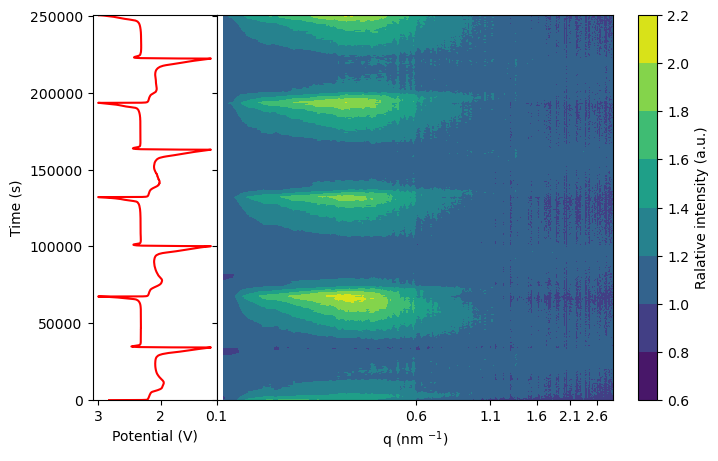

In [75]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
contourplot('saxs', 'relative', saxs_data, new_time_dict, 0.13, 3)

# Background correction with empty cell subtraction 

(0.01, 6)

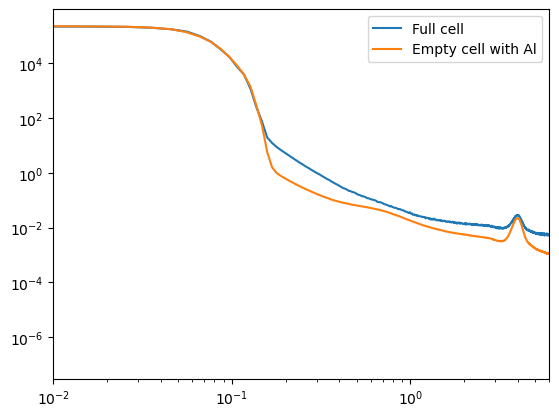

In [93]:
plt.figure()  

plt.plot(10*saxs_data[file_names[0]].iloc[:,0],saxs_data[file_names[0]].iloc[:,1], label = 'Full cell')
plt.plot(10*SAXS_background.iloc[:,0], SAXS_background.iloc[:,1], label = 'Empty cell with Al')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.xlim(0.01,6)
#plt.ylim(0.001,40)
#print(SAXS_background)
# print(file_dictionary[1].head())
# print(file_dictionary[250].head())

# Create a new dictionary with corrected SAXS

(0.0001, 40)

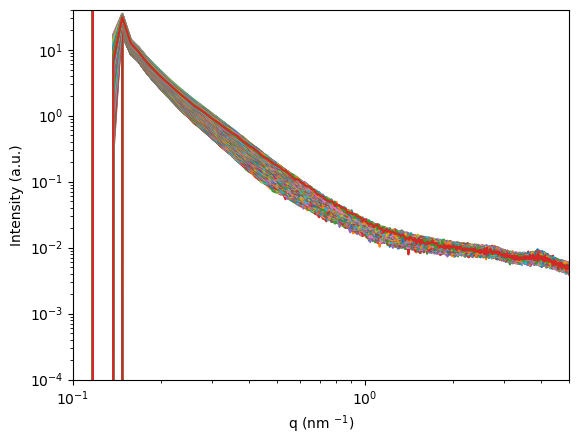

In [94]:
plt.figure()
emptyCell_corrected_saxs_files = {}
for ikey in saxs_data:
    X_data = saxs_data[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = saxs_data[ikey].iloc[:,1]
    modified_Y = Y_data - SAXS_background.iloc[:len(Y_data),1]
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    emptyCell_corrected_saxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(0.1,5)
plt.ylim(0.0001,40)
#print(corrected_waxs_files[1].head(30))

profile for cycle number: 1 to 4
5 174 1236


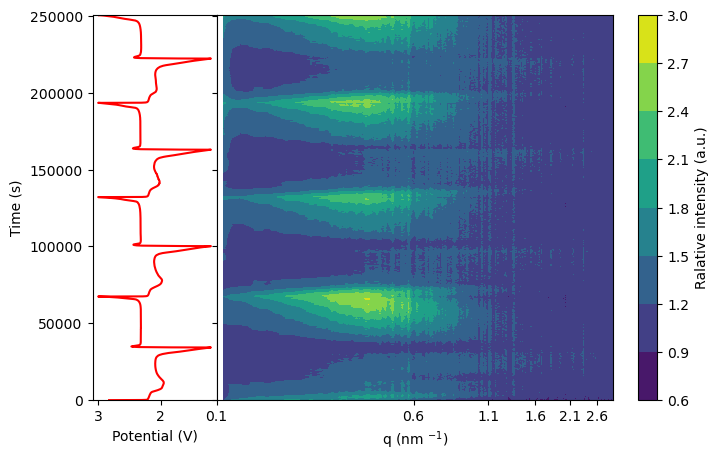

In [88]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
contourplot('saxs', 'relative', emptyCell_corrected_saxs_files, new_time_dict, 0.14, 3)

# Manual correction with perticular curve

# WAXS data polotting

Text(0, 0.5, 'Intensity (a.u.)')

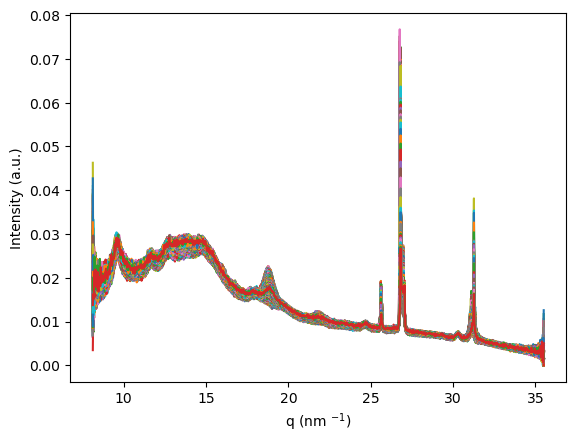

In [95]:
#df_log = df[1].apply(np.log, axis=0)
plt.style.use('default')
for ikey in waxs_data:
    X_data = 10*waxs_data[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = waxs_data[ikey].iloc[:,1]
    plt.plot(X_data, Y_data)
#    plt.legend(legend[ikey])
    
#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
#check

profile for cycle number: 1 to 4
5 174 1236


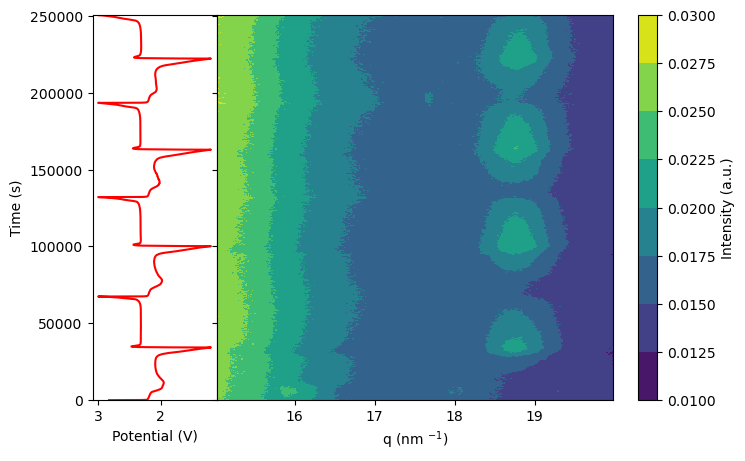

In [97]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
contourplot('waxs', 'absolute', waxs_data, new_time_dict, 15, 20)

# Background correction and plotting for the WAXS

# Background correction with empty cell subtraction 

Text(0, 0.5, 'Intensity (a.u.)')

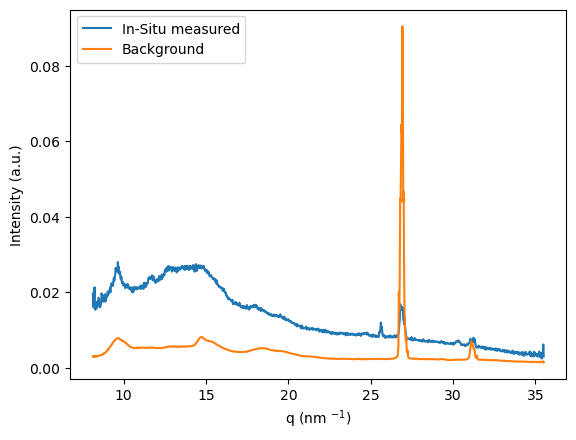

In [99]:
file_names_waxs = list(waxs_data.keys())
plt.plot(10*waxs_data[file_names_waxs[0]].iloc[:,0], waxs_data[file_names_waxs[0]].iloc[:,1], label = "In-Situ measured")
plt.plot(10*WAXS_background.iloc[:,0], WAXS_background.iloc[:,1], label = 'Background')
plt.legend()
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')

(-0.02, 0.05)

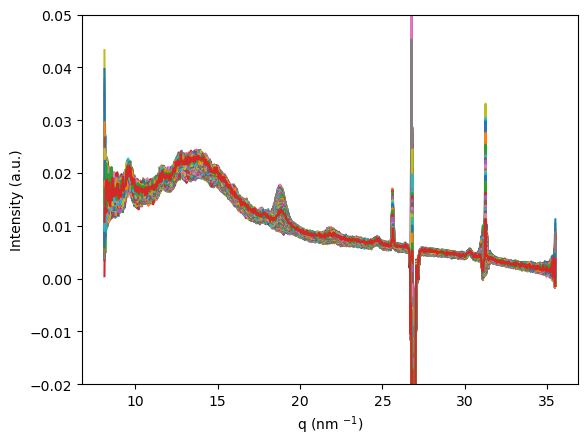

In [100]:
emptyCell_corrected_waxs_files = {}
for ikey in waxs_data:
    X_data = waxs_data[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = waxs_data[ikey].iloc[:,1]
    modified_Y = Y_data - WAXS_background.iloc[:,1]
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    emptyCell_corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
plt.ylim(-0.02,0.05)
#print(corrected_waxs_files[1].head(30))

profile for cycle number: 1 to 4
5 174 1236
5 174 1236


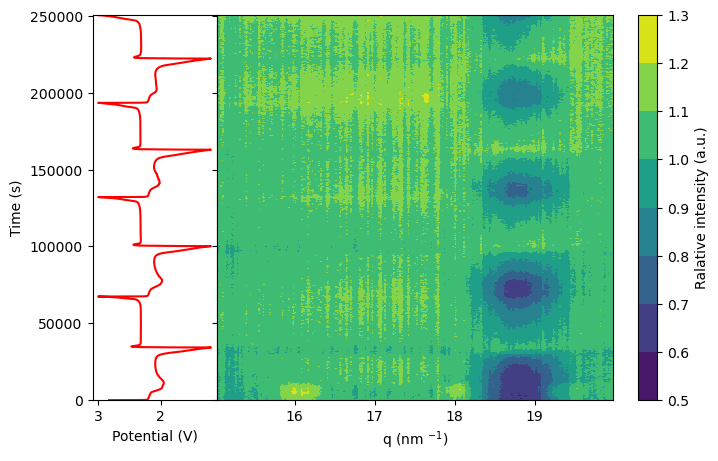

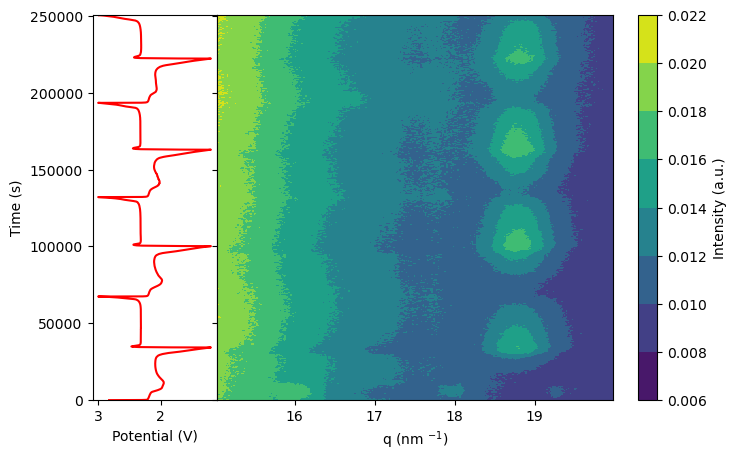

In [101]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
contourplot('waxs', 'relative', emptyCell_corrected_waxs_files, new_time_dict, 15, 20)
contourplot('waxs', 'absolute', emptyCell_corrected_waxs_files, new_time_dict, 15, 20)

# Background correction with a polynomial

In [ ]:
X_data = []
Y_data = []

for files in range(1,4):
    if files == 1:
        X_data = 10*file_dictionary_waxs[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        Y_data = file_dictionary_waxs[files].iloc[:,1]
    else:
        x = 10*file_dictionary_waxs[files].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
        y = file_dictionary_waxs[files].iloc[:,1]
        X_data += x
        Y_data += y

for entries in range(len(X_data)):
    X_data[entries] = X_data[entries]/3
    Y_data[entries] = Y_data[entries]/3

baseline_filter = Baseline(x_data = X_data)
baseline = baseline_filter.modpoly(Y_data, poly_order= 6)[0]
print(baseline)
modified_Y = Y_data-baseline
plt.plot(X_data, Y_data)
plt.plot(X_data, baseline)
plt.plot(X_data, modified_Y)

output_filename = "corrected_waxs.txt"
with open(output_filename, 'w') as f:
    for x,y in zip(X_data, modified_Y):
        f.write(f"{x}\t{y}\n")

print(f"first file printed as {output_filename}")

# Create background corrected WAXS dataframe

plt.figure("After polynomial background correction")

corrected_waxs_files = {}
for ikey in file_dictionary_waxs:
    X_data = file_dictionary_waxs[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary_waxs[ikey].iloc[:,1]
    modified_Y = Y_data - baseline
    plt.plot(10*X_data, modified_Y)
    df = pd.DataFrame({'X_data': X_data, 'Modified_Y': modified_Y})
    corrected_waxs_files[ikey] = df

#Setting graph attributes
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')
#print(corrected_waxs_files[1].head(30))


# Colour plot of Background corrected WAXS

In [ ]:
print(f'profile for cycle number: {starting_cycle} to {end_cycle}')
contourplot('waxs', 'absolute', corrected_waxs_files, new_time_dict, waxs_min_limit, waxs_max_limit)

# Manually plot certain saxs and waxs file

In [ ]:
# Manual data plotting SAXS

for ikey in range(1,10):
    X_data = 10*file_dictionary[ikey].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = file_dictionary[ikey].iloc[:,1]
    plt.plot(X_data, Y_data)
plt.xlabel('q (nm $^{-1}$)')
plt.ylabel('Intensity (a.u.)')

plt.xscale('log')
plt.yscale('log')

In [ ]:
# Manual data plotting WAXS
plt.figure()
for ikey in range(169,170):
    X_data = 10*emptyCell_corrected_saxs_files[169].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = emptyCell_corrected_saxs_files[169].iloc[:,1]
    plt.plot(X_data, Y_data)
for ikey in range(1,2):
    X_data = 10*emptyCell_corrected_saxs_files[1].iloc[:,0] # multipled by 10 to convert from inverse Angstrom to inverse nanometer 
    Y_data = emptyCell_corrected_saxs_files[1].iloc[:,1]
    plt.plot(X_data, Y_data)
plt.xscale('log')
plt.yscale('log')